# Visualizing the saliency maps

Once your classifier is trained you can visualize which pixels where the most relevant to classify an image as a certain label. This is what we call the *saliency maps*.

We will use the implementations of different saliency functions from the [deep-viz repository](https://github.com/experiencor/deep-viz-keras) by [experiencor](https://github.com/experiencor) which allows the visualization of saliency maps for keras models.



In [1]:
import os
import json

import numpy as np
import matplotlib.pylab as plt
from tensorflow.keras.models import load_model

from planktonclass import paths, utils, data_utils
from planktonclass.data_utils import load_data_splits, load_class_names, k_crop_data_sequence
from planktonclass.test_utils import predict
from planktonclass.visualization.saliency import GradientSaliency
from planktonclass.visualization.guided_backprop import GuidedBackprop
from planktonclass.visualization.integrated_gradients import IntegratedGradients
from planktonclass.visualization.visual_backprop import VisualBackprop

# User parameters to set
TIMESTAMP = 'cyto_model'                       # timestamp of the model
MODEL_NAME = 'final_model.h5'                           # model to use to make the prediction
TOP_K = 5                                               # number of top classes predictions to save

# Set the timestamp
paths.timestamp = TIMESTAMP

# Load the data
class_names = load_class_names(splits_dir=paths.get_ts_splits_dir())

# Load training configuration
conf_path = os.path.join(paths.get_conf_dir(), 'conf.json')
with open(conf_path) as f:
    conf = json.load(f)
    
# Load the model
model = load_model(os.path.join(paths.get_checkpoints_dir(), MODEL_NAME), custom_objects=utils.get_custom_objects())

c:\Users\wout.decrop\Documents\environments\phytoplankton_classifier\phytoplankton_env\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):
2026-03-23 11:58:03 - planktonclass.data_utils - INFO - [data] Loading class names


In [2]:
import os
import json
from planktonclass import test_utils
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix,roc_auc_score
from planktonclass.data_utils import load_image, load_class_names
from planktonclass import paths, plot_utils
from planktonclass.plot_utils import create_pred_path,plt_conf_matrix
import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import seaborn
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore") # To ignore UndefinedMetricWarning: [Recall/Precision/F-Score] is ill-defined and being set to 0.0 in labels with no [true/predicted] samples.
# User parameters to set
SPLIT_NAME = 'DS_split'                   # dataset split to predict


# Set the timestamp
paths.timestamp = TIMESTAMP

# Load clas names
class_names = load_class_names(splits_dir=paths.get_ts_splits_dir())

# Load back the predictions
pred_path = os.path.join(paths.get_predictions_dir(), '{}+{}+top{}.json'.format(MODEL_NAME, SPLIT_NAME, TOP_K))
with open(pred_path) as f:
    pred_dict = json.load(f)
data = pd.DataFrame(pred_dict)
data[['filenames', 'true_lab','pred_lab']].head(5)
data['in_top5'] = data.apply(lambda row: row['true_lab'] in row['pred_lab'], axis=1)
data['top1_correct'] = data.apply(lambda row: row['true_lab'] == row['pred_lab'][0], axis=1)
data['true_label']=class_names[data['true_lab']]
data['top1']=data.apply(lambda row: class_names[row['pred_lab'][0]], axis=1)
data['probability']=data.apply(lambda row: row['pred_prob'][0], axis=1)
flat_array=np.concatenate(np.array(pred_dict['pred_lab']))
data['pred_lab'] = flat_array.reshape(-1, 5)

2026-03-23 11:58:05 - planktonclass.data_utils - INFO - [data] Loading class names


[1/3] GradientSaliency
[2/3] GuidedBackprop
[3/3] IntegratedGradients
⚙ GPU is NOT available. Using CPU.
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Top predicted labels:
[72.0%] Coccolithaceae
[23.9%] Dinoflagellata
[3.7%] Ciliophora
[0.2%] dinoflagellate-cysts
[0.1%] Cryptophyceae


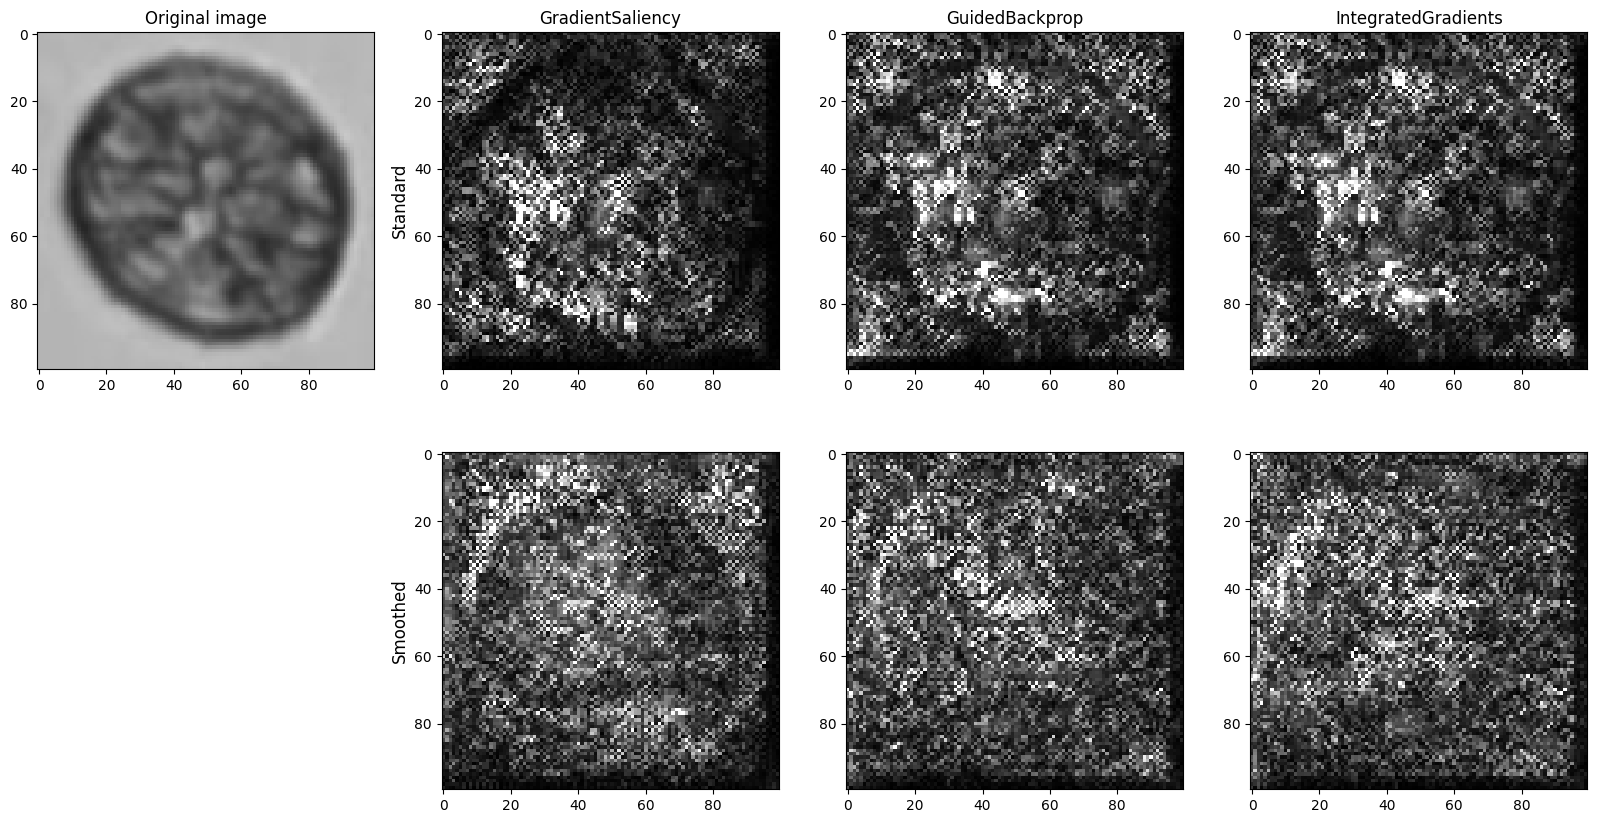

In [3]:
FILEPATH = rf'..\data\images\Actinoptychus\ecotaxa_Actinoptychus_0A287917-C897-49F5-8CBF-633895467766.jpg'
saliency_types = [GradientSaliency, GuidedBackprop, IntegratedGradients]#, VisualBackprop] --> VisualBackprop seems to give errors

figsize = 5
fig, axs = plt.subplots(2, len(saliency_types)+1, figsize=(figsize*(len(saliency_types)+1), figsize*2))
axs = axs.T.flatten()

# Load the image and preprocess it for the saliency maps computation
data_gen = k_crop_data_sequence(inputs=[FILEPATH],
                                im_size=conf['model']['image_size'],
                                mean_RGB=conf['dataset']['mean_RGB'],
                                std_RGB=conf['dataset']['std_RGB'],
                                preprocess_mode=conf['model']['preprocess_mode'],
                                aug_params=None,
                                crop_mode='random',
                                crop_number=1,
                                filemode='local')

img_arr = data_gen.__getitem__(0)
img_arr = img_arr.squeeze(axis=0)

# Original image
image = data_utils.load_image(FILEPATH, filemode='local')
image = data_utils.resize_im(image, height=conf['model']['image_size'], width=conf['model']['image_size'])
axs[0].imshow(image)
axs[0].set_title('Original image', fontsize=12)
fig.delaxes(axs[1])
axs = axs[2:]

# Saliency maps
axs[0].set_ylabel('Standard', fontsize=12)
axs[1].set_ylabel('Smoothed', fontsize=12)
for i, f in enumerate(saliency_types):
    print('[{}/{}] {}'.format(i+1, len(saliency_types), f.__name__))
    saliency_func = f(model)
    
    # Normal map
    mask = saliency_func.get_mask(img_arr)
    mask = np.sum(np.abs(mask), axis=2)
    axs[i*2].imshow(mask, cmap=plt.cm.gray, vmin=np.amin(mask), vmax=np.percentile(mask, 98))
    axs[i*2].set_title(saliency_func.__class__.__name__, fontsize=12)
    
    # Smoothgrad map
    mask = saliency_func.get_smoothed_mask(img_arr)
    mask = np.sum(np.abs(mask), axis=2)
    axs[i*2+1].imshow(mask, cmap=plt.cm.gray, vmin=np.amin(mask), vmax=np.percentile(mask, 98))
    
# Print predicted labels
pred_lab, pred_prob = predict(model, FILEPATH, conf, top_K=TOP_K, filemode='local')
print('Top predicted labels:')
for j in range(pred_lab.shape[1]):
    print('[{:.1f}%] {}'.format(pred_prob[0, j] * 100, class_names[pred_lab[0, j]]))

['..\\data\\images\\Actinoptychus\\ecotaxa_Actinoptychus_00D9D0C4-D41A-42E8-9FA2-6F9985B39865.jpg', '..\\data\\images\\Actinoptychus\\ecotaxa_Actinoptychus_0A02C03F-CE0F-420C-8325-8F1AC79B5F63.jpg', '..\\data\\images\\Actinoptychus\\ecotaxa_Actinoptychus_0A22C4BE-822E-4653-838A-51D837D89E8D.jpg', '..\\data\\images\\Actinoptychus\\ecotaxa_Actinoptychus_0A287917-C897-49F5-8CBF-633895467766.jpg', '..\\data\\images\\Actinoptychus\\ecotaxa_Actinoptychus_0A3E62B8-620B-4B38-8E11-149A509315CC.jpg', '..\\data\\images\\Actinoptychus\\ecotaxa_Actinoptychus_0A4655A3-123D-4A0A-A55F-3302620763B6.jpg', '..\\data\\images\\Actinoptychus\\ecotaxa_Actinoptychus_0A6A182E-69D1-4136-B332-CCB4BD8B0EDB.jpg', '..\\data\\images\\Actinoptychus\\ecotaxa_Actinoptychus_0AB28ACD-9394-4E08-8731-22BB01D27C39.jpg', '..\\data\\images\\Actinoptychus\\ecotaxa_Actinoptychus_0AB4C8AB-018E-4586-80FF-82322C376678.jpg', '..\\data\\images\\Actinoptychus\\ecotaxa_Actinoptychus_0C415579-5E23-4F81-838D-049F68E34294.jpg', '..\\data

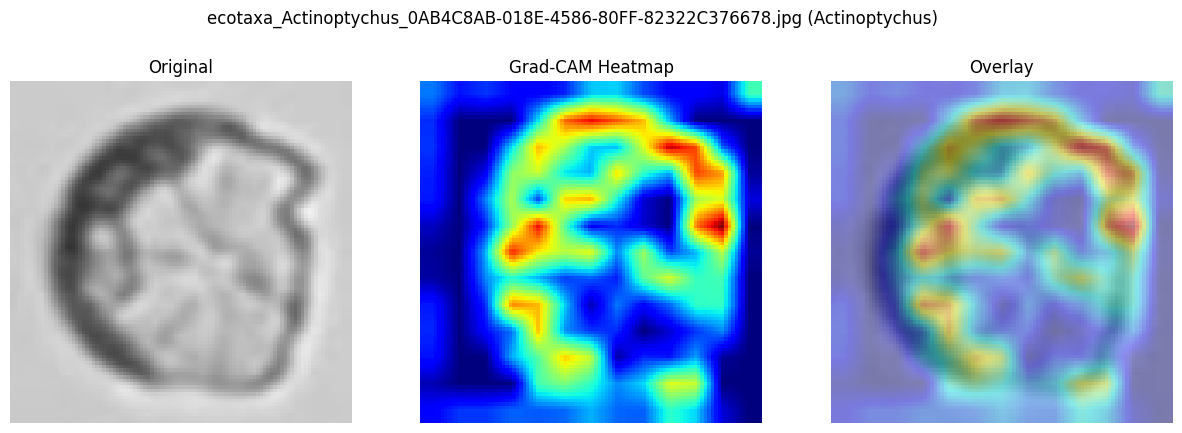

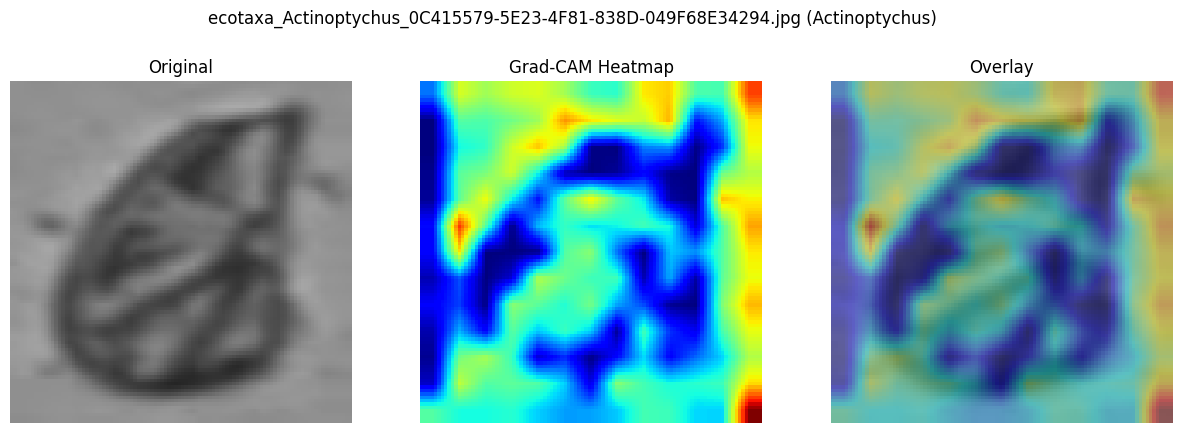

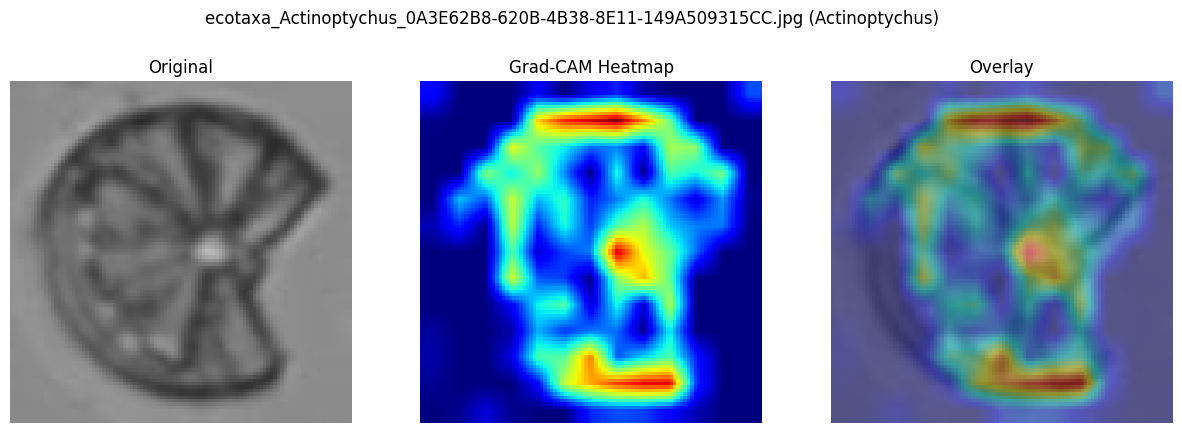

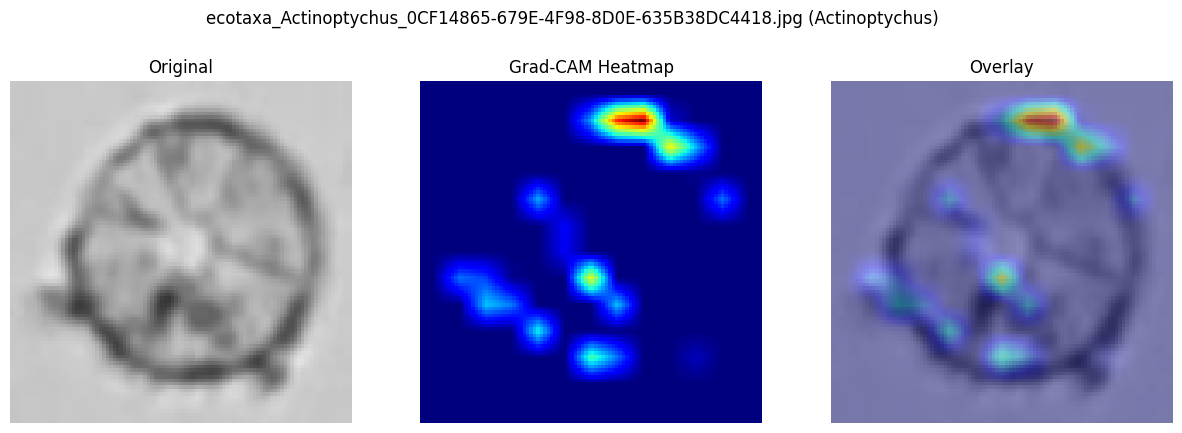

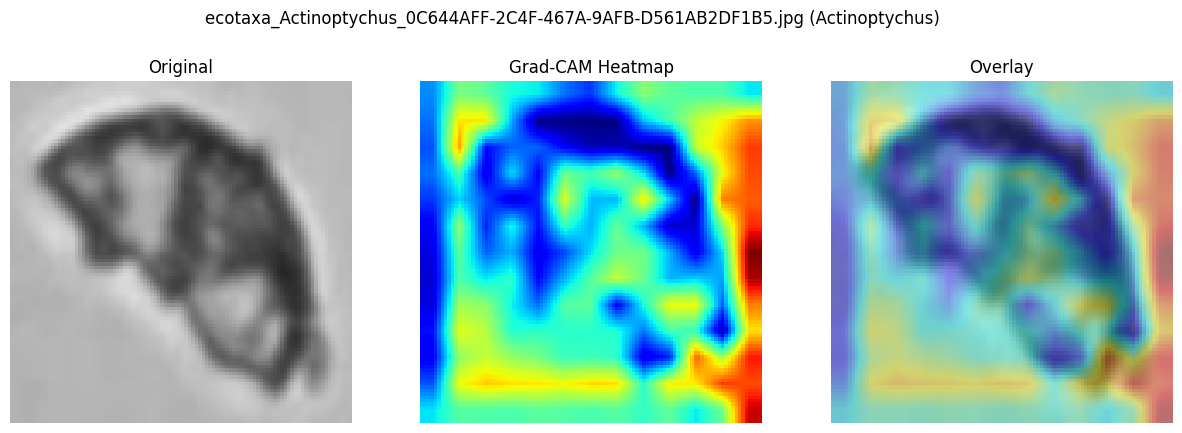

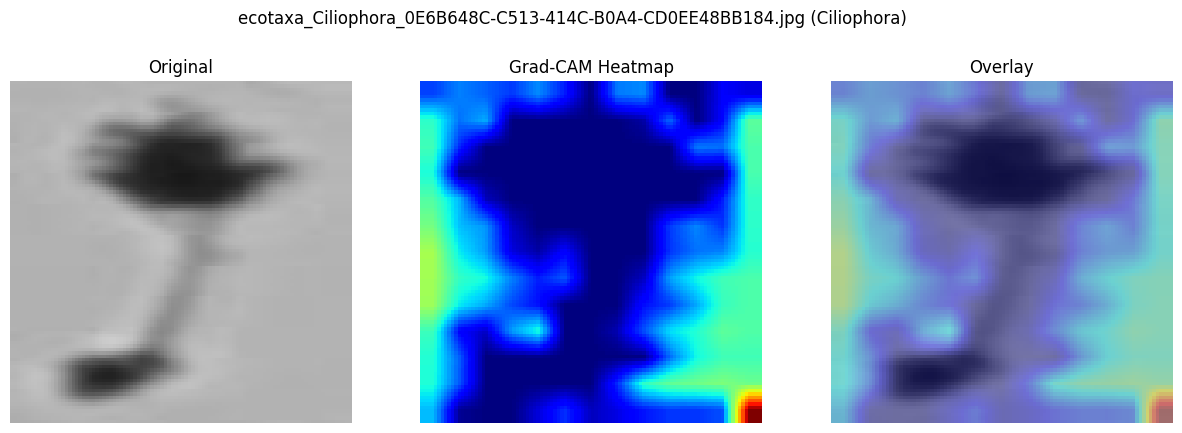

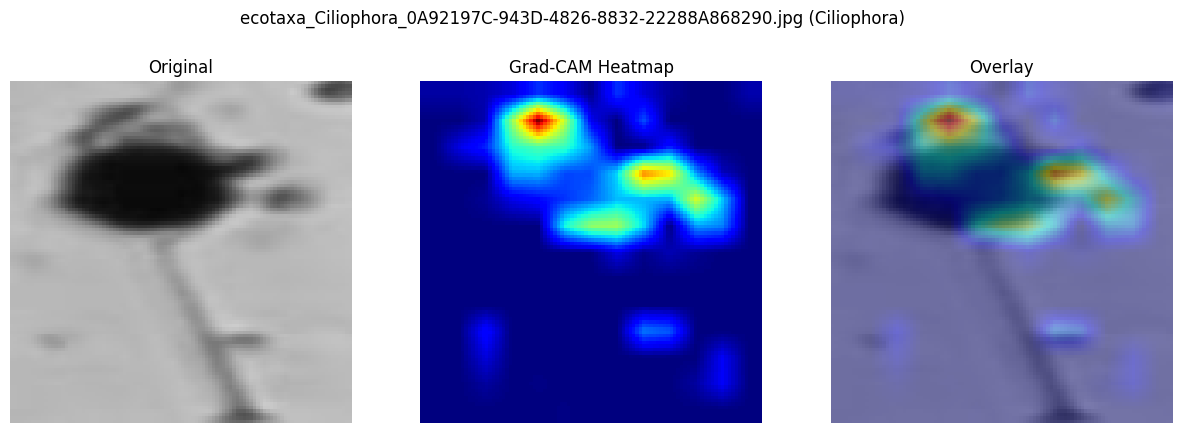

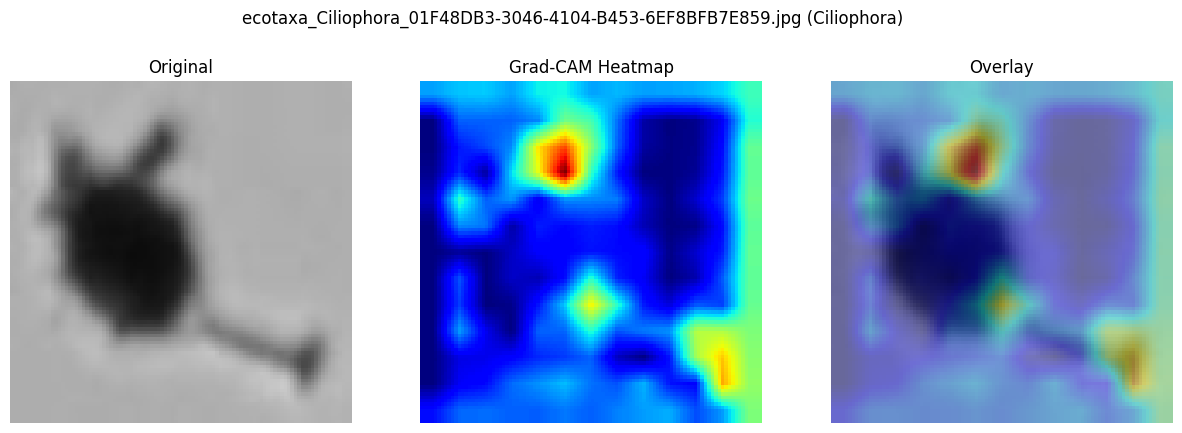

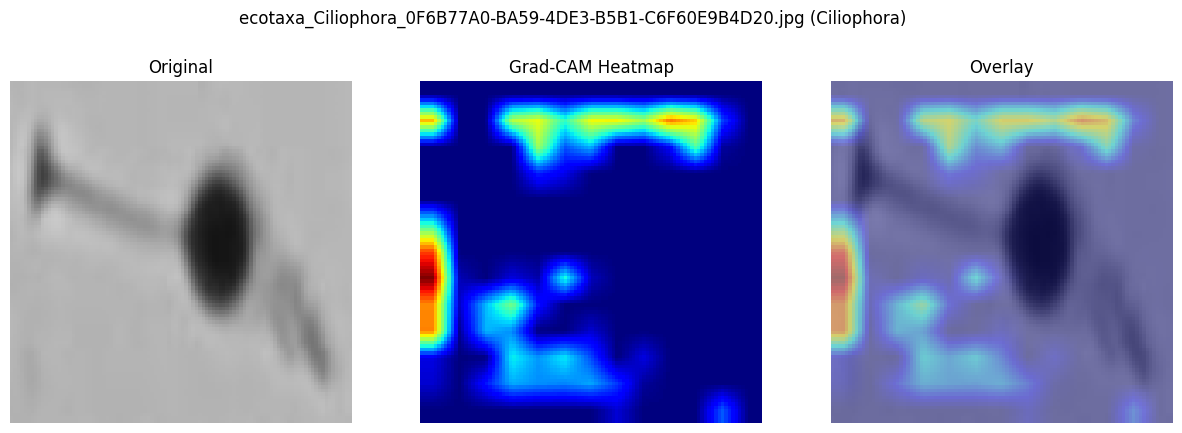

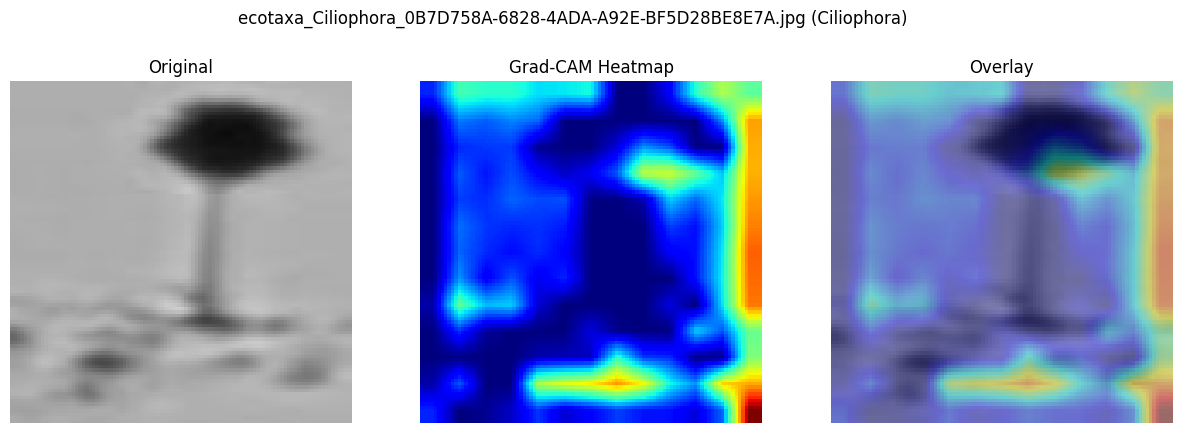

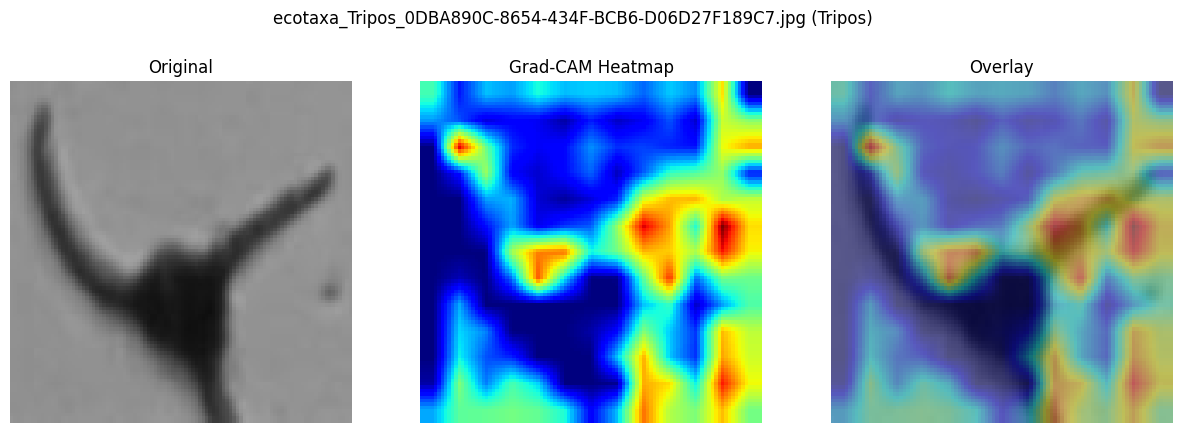

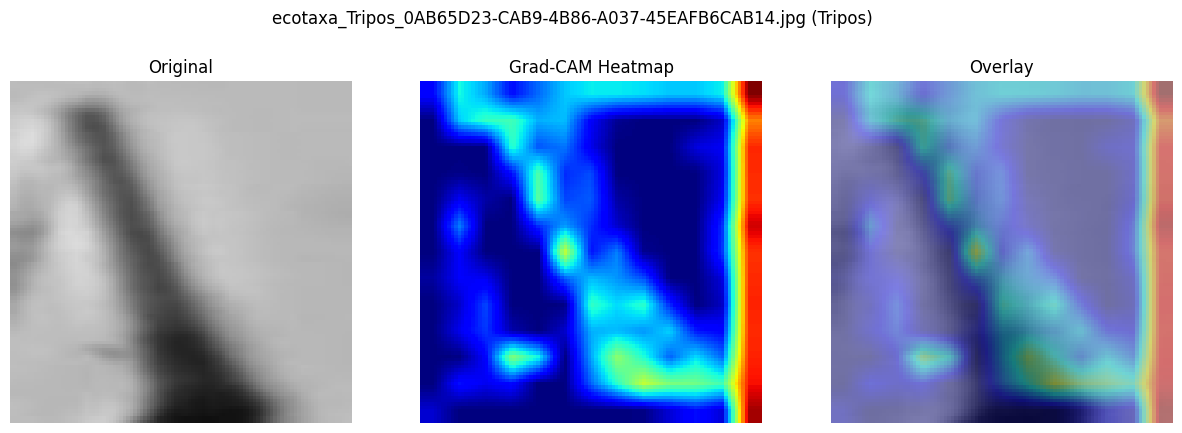

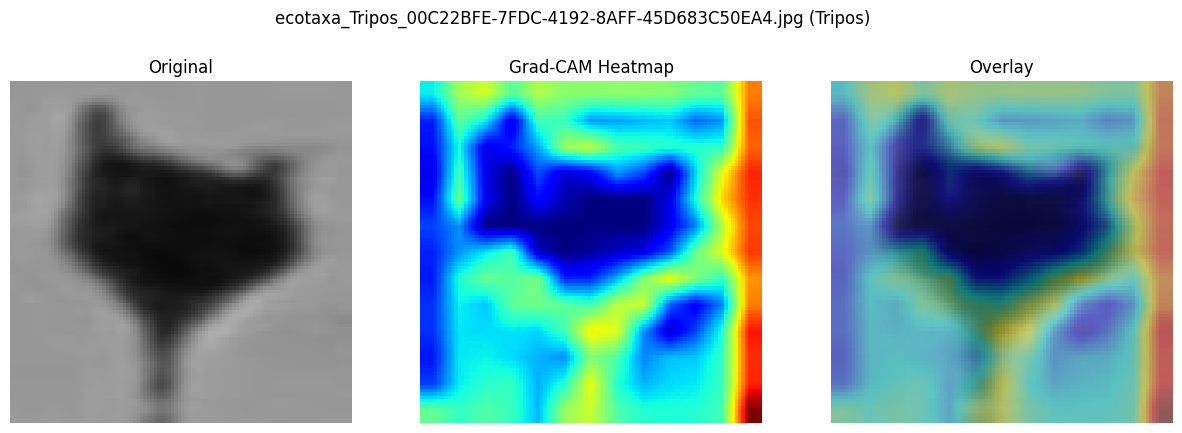

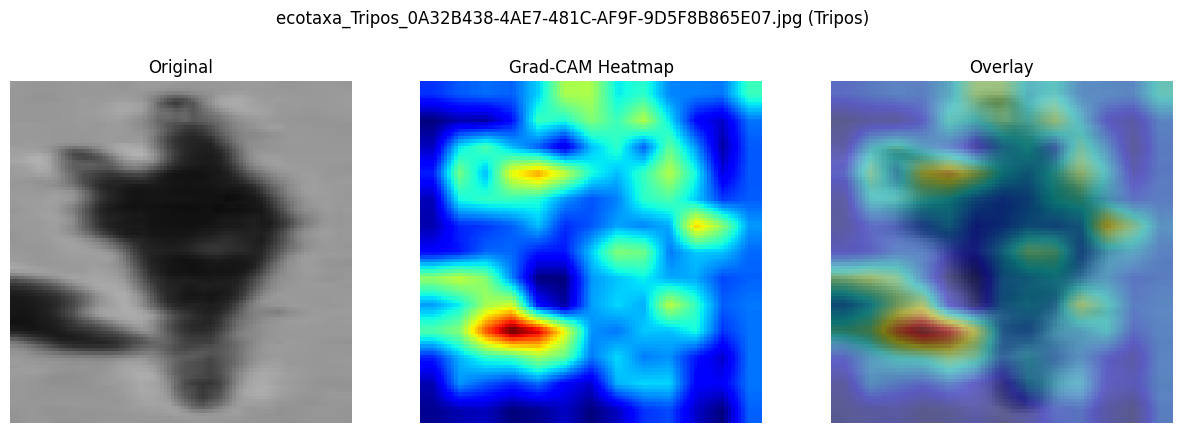

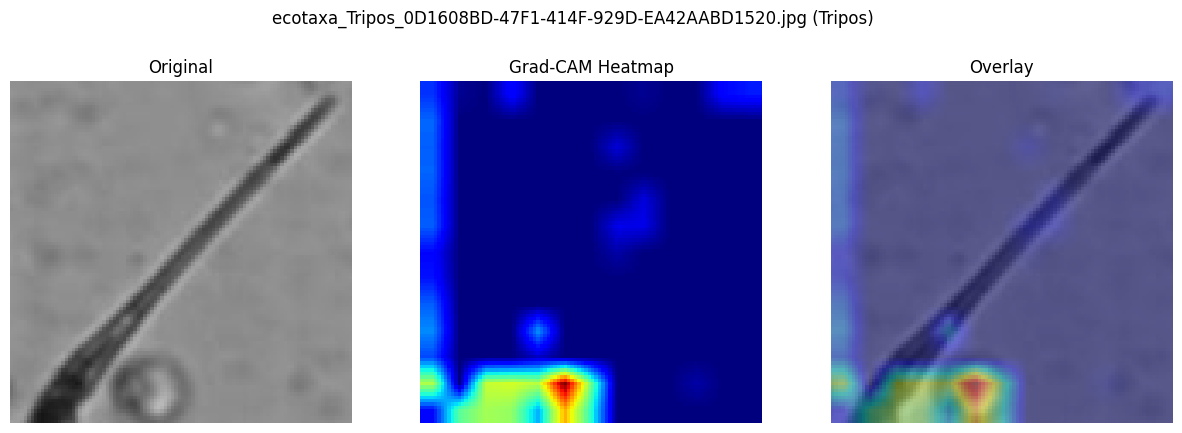

In [4]:
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import load_model

from planktonclass import paths, utils, data_utils
from planktonclass.data_utils import k_crop_data_sequence

# ---- USER INPUTS ----
DATA_DIR = rf'..\data\images'
LAYER_NAME = "block3a_expand_conv"

# Classes suggested in discussion
PRIORITY_CLASSES = [
    'Actinoptychus', 'Ciliophora', 'Tripos'
]
NUM_PER_CLASS = 5  # number of random images per class

# ---- LOAD CONFIG ----
paths.timestamp = TIMESTAMP
import json
conf_path = os.path.join(paths.get_conf_dir(), 'conf.json')
with open(conf_path) as f:
    conf = json.load(f)

# ---- LOAD MODEL ----
model = load_model(os.path.join(paths.get_checkpoints_dir(), MODEL_NAME), custom_objects=utils.get_custom_objects())

# ---- HELPER FUNCTIONS ----
def load_random_images_from_classes(data_dir, classes, num_per_class=2):
    selected_files = []
    for cls in classes:
        class_dir = os.path.join(data_dir, cls)
        if not os.path.exists(class_dir):
            print("exists not")
            continue
        files = [os.path.join(class_dir, f) for f in os.listdir(class_dir) 
                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        print(files)
        selected_files.extend(random.sample(files, min(num_per_class, len(files))))
    return selected_files

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs], 
        [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(np.expand_dims(img_array, axis=0))

        # If model has multiple outputs
        if isinstance(predictions, list):
            predictions = predictions[0]

        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# ---- PROCESS IMAGES ----
sample_files = load_random_images_from_classes(DATA_DIR, PRIORITY_CLASSES, NUM_PER_CLASS)

for img_path in sample_files:
    # Preprocess image
    data_gen = k_crop_data_sequence(
        inputs=[img_path],
        im_size=conf['model']['image_size'],
        mean_RGB=conf['dataset']['mean_RGB'],
        std_RGB=conf['dataset']['std_RGB'],
        preprocess_mode=conf['model']['preprocess_mode'],
        aug_params=None,
        crop_mode='random',
        crop_number=1,
        filemode='local'
    )
    img_arr = data_gen.__getitem__(0).squeeze(axis=0)
    
    # Load original for overlay
    image = data_utils.load_image(img_path, filemode='local')
    image = data_utils.resize_im(image, height=conf['model']['image_size'], width=conf['model']['image_size'])
    
    # Grad-CAM
    heatmap = make_gradcam_heatmap(img_arr, model, LAYER_NAME)
    heatmap_resized = cv2.resize(heatmap, (image.shape[1], image.shape[0]))
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(image, 0.6, heatmap_color, 0.4, 0)
    
    # Display results
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(image)
    axs[0].set_title('Original')
    axs[0].axis('off')
    
    axs[1].imshow(heatmap_resized, cmap='jet')
    axs[1].set_title('Grad-CAM Heatmap')
    axs[1].axis('off')
    
    axs[2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    axs[2].set_title('Overlay')
    axs[2].axis('off')
    
    plt.suptitle(f"{os.path.basename(img_path)} ({os.path.basename(os.path.dirname(img_path))})")
    plt.show()